In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the dataset
heart_data = pd.read_csv('Dataset/Heart.csv', index_col=0)

# Take a quick look at the dataframe
heart_data


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [9]:
# Assign Max Heart Rate as the predictor
x = heart_data.MaxHR

# Assign AHD as the response variable
# Replace the string column values to 0 and 1
y = heart_data.AHD.map({"No":0,"Yes":1})


/var/folders/8v/r7l3cx490g963phcl1nghxzc0000gp/T/ipykernel_81108/2516031642.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


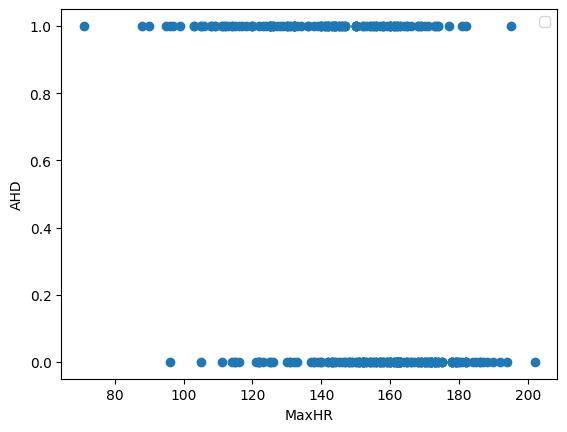

In [4]:
# Plot the predictor and reponse vairables as a scatter plot 
# with appropriate axes label
plt.scatter(x,y)
plt.xlabel("MaxHR")
plt.ylabel("AHD")
plt.legend(loc='best')


In [11]:
### edTest(test_affine) ###

# Function to perform affine transformation
def affine(x, w, b):
    """Return affine transformation of x
    
    INPUTS
    ======
    x: A numpy array of points in x
    w: A float representing the weight of the perceptron
    b: A float representing the bias of the perceptron
    
    RETURN
    ======
    z: A numpy array of points after the affine transformation
    """
    # This works for scalar values only
    # Your code here
    z = b + (x*w)
    return z


In [5]:
### edTest(test_sigmoid) ###

# Function to apply sigmoid function on the parameter
def sigmoid(z):
    # Hint: numpy has an exponentiation function, np.exp()
    
    # Your code here
    h = 1/(1+np.exp(-z))
    return h


In [6]:
### edTest(test_neuron_predict) ###

# Function to combine the previous operations
def neuron_predict(x, w, b):

    # Call the previous functions
    # Your code here
    z = affine(x, w, b)
    h = sigmoid(z)
    return h
    

In [7]:
# Hint: Try values between -1 and 1
w = -.5

# Hint: Try values between 50 and 100
b = 67


In [12]:
# The forward mode or predict of a single neuron

# Create evenly spaced values of x to predict on
x_linspace = np.linspace(x.min(),x.max(),500) 
h = neuron_predict(x_linspace,w, b)


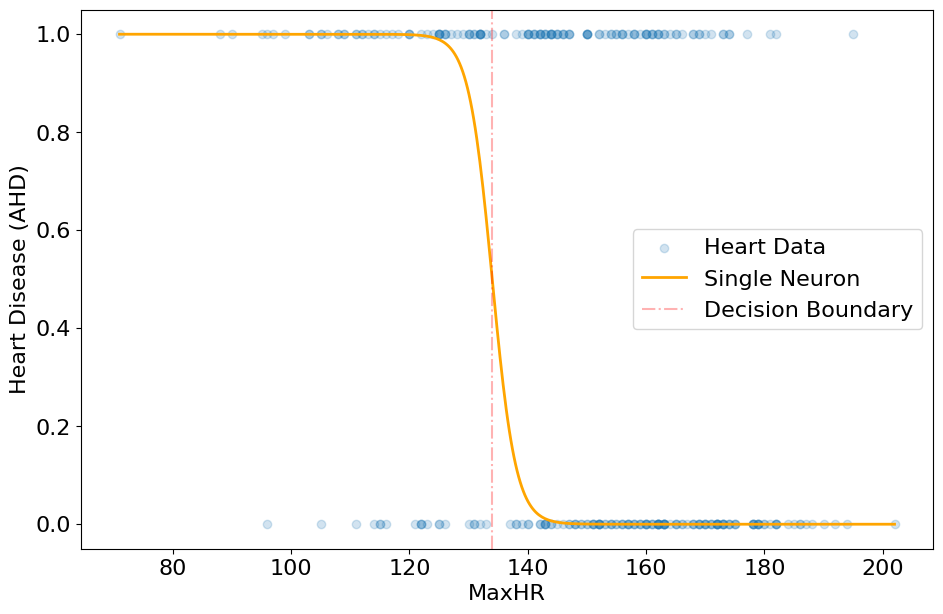

In [13]:
# Plot Predictions
fig, ax = plt.subplots(1,1, figsize=(11,7))
ax.scatter(x, y, label=r'Heart Data', alpha=0.2)
ax.plot(x_linspace, h, lw=2, c='orange', label=r'Single Neuron')

# First value in x_linspace with a probability < 0.5
db = x_linspace[np.argmax(h<0.5)] 
ax.axvline(x=db, alpha=0.3, linestyle='-.', c='r', label='Decision Boundary')

# Proper plot labels are very important!

# Make the tick labels big enough to read
ax.tick_params(labelsize=16)
plt.xlabel('MaxHR', fontsize=16)
plt.ylabel('Heart Disease (AHD)', fontsize=16)

# Create a legend and make it big enough to read
ax.legend(fontsize=16, loc='best') 
plt.show()


In [14]:
def loss(y_true, y_pred, eps=1e-15):
    assert y_true.shape[0] == y_pred.shape[0]
    
    # Clipping
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -sum(y_true*np.log(y_pred) + (1-y_true)*(np.log(1-y_pred)))

In [15]:
## Print the loss of the single neuron model
h = neuron_predict(x, w, b)
print(loss(y, h))


988.5079666830608


In [16]:
def accuracy(y_true, y_pred):
    assert y_true.shape[0] == y_pred.shape[0]
    return sum(y_true == (y_pred >= 0.5).astype(int))/len(y_true)
    

In [17]:

# For the baseline predictions are all ones
baseline_acc = accuracy(y, np.ones(len(y))) 
perceptron_acc = accuracy(y, h)
print(f'Baseline Accuracy: {baseline_acc:.2%}')
print(f'Perceptron Accuracy: {perceptron_acc:.2%}')


Baseline Accuracy: 45.87%
Perceptron Accuracy: 66.34%
